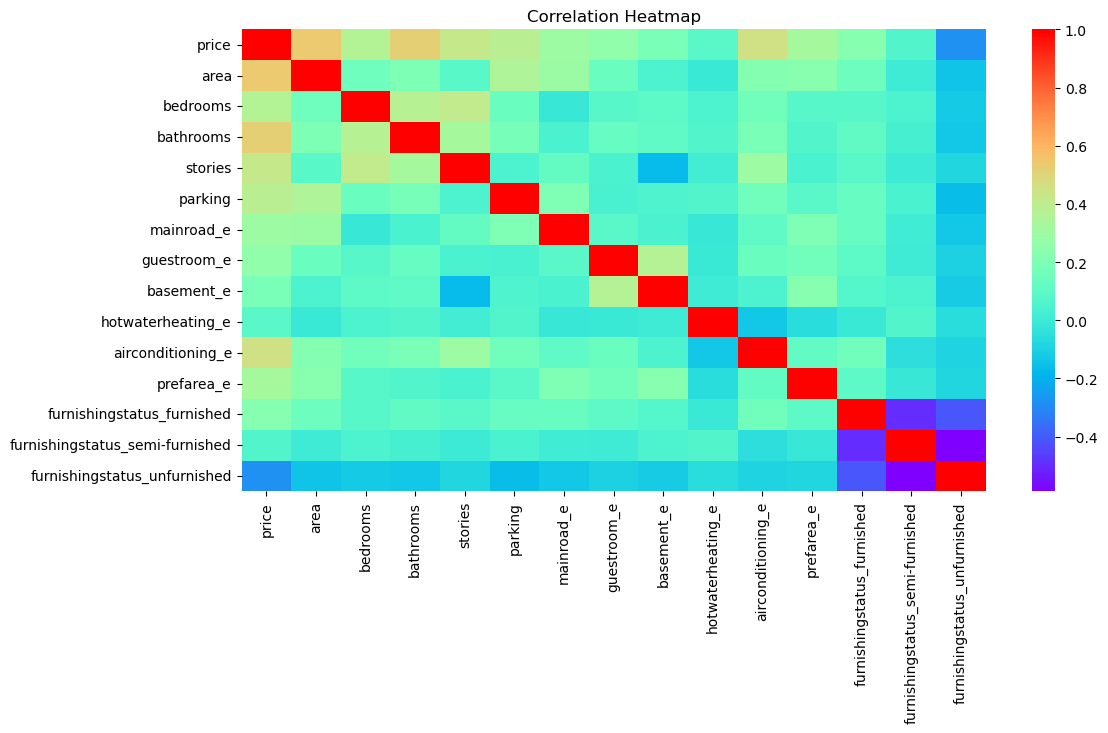

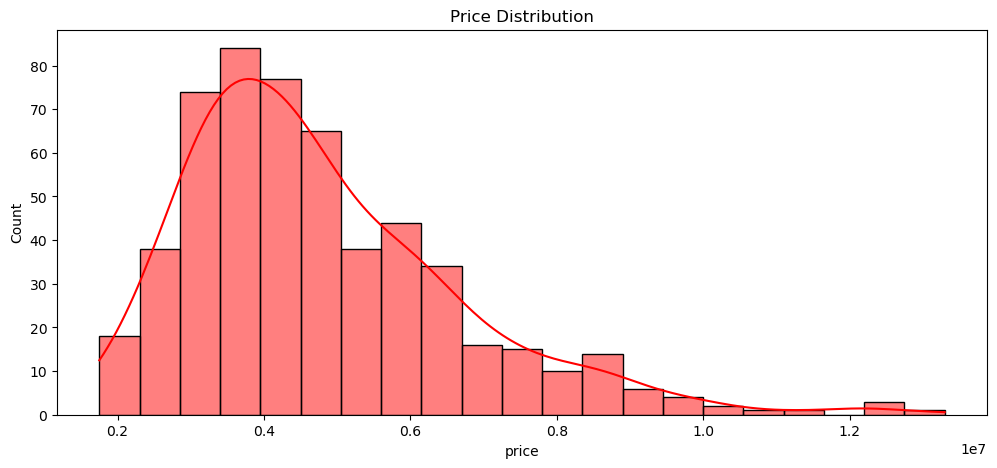

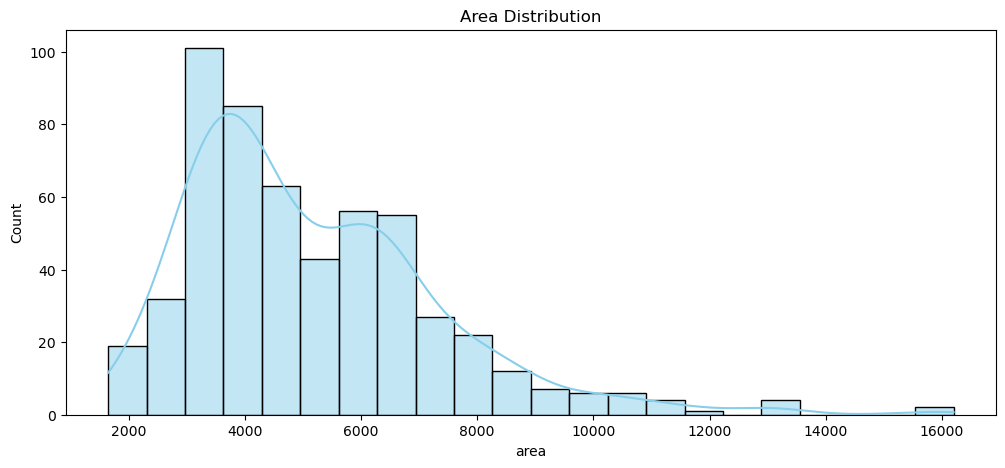

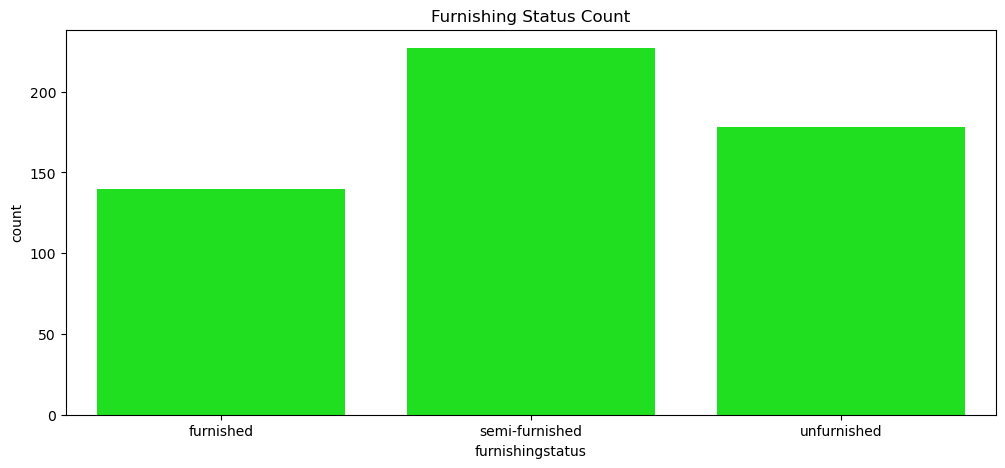

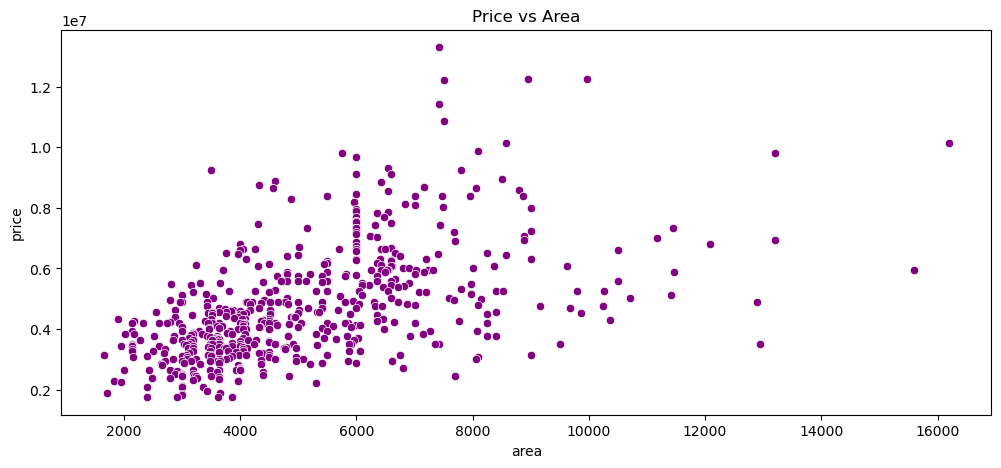

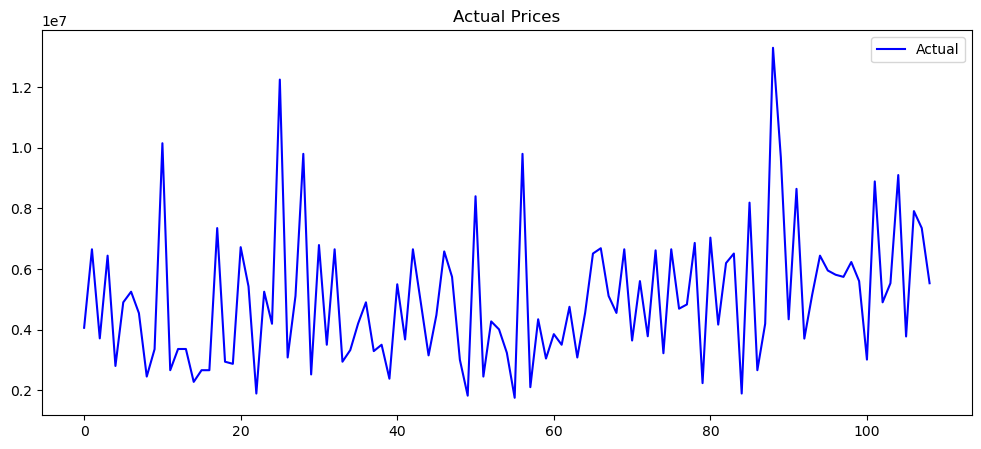

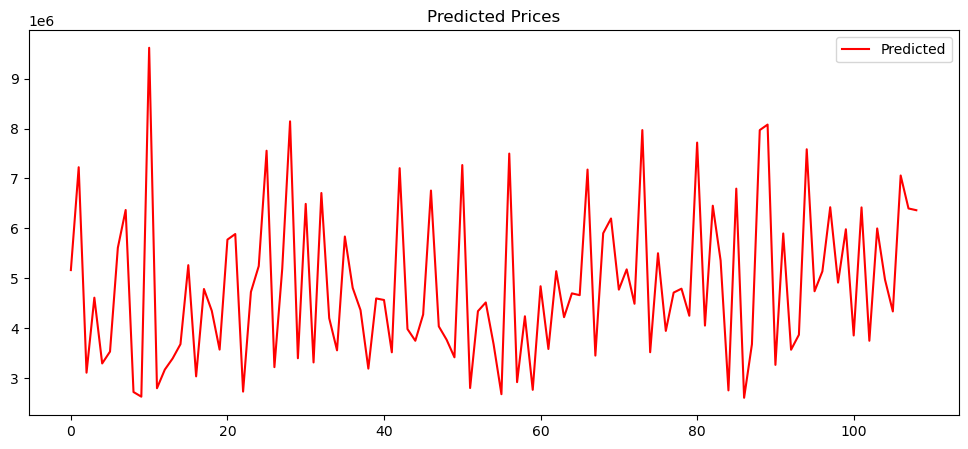

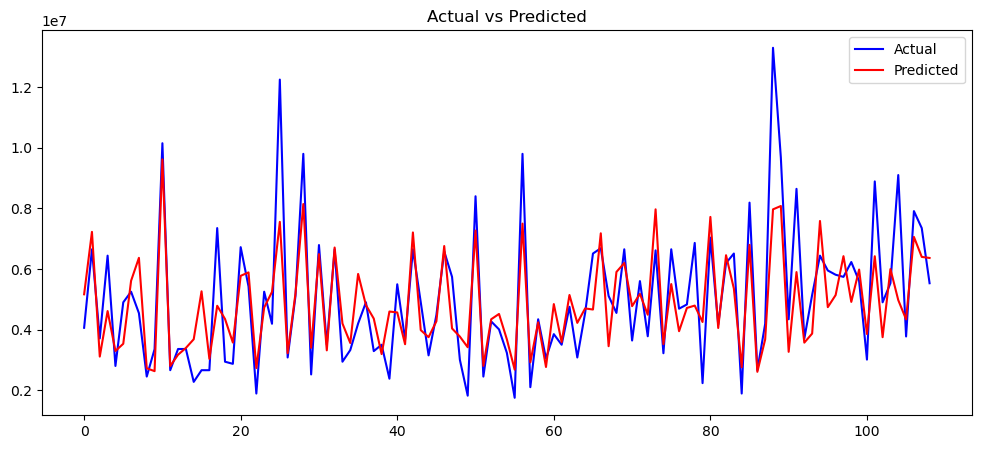

Enter House Details


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('Housing.csv')
data = df.copy()

le = LabelEncoder()

data['mainroad_e'] = le.fit_transform(data['mainroad'])
data['guestroom_e'] = le.fit_transform(data['guestroom'])
data['basement_e'] = le.fit_transform(data['basement'])
data['hotwaterheating_e'] = le.fit_transform(data['hotwaterheating'])
data['airconditioning_e'] = le.fit_transform(data['airconditioning'])
data['prefarea_e'] = le.fit_transform(data['prefarea'])

data = pd.get_dummies(data, columns=['furnishingstatus'])

X = data[[
    'area','bedrooms','bathrooms','stories',
    'mainroad_e','guestroom_e','basement_e',
    'hotwaterheating_e','airconditioning_e',
    'prefarea_e','parking',
    'furnishingstatus_furnished',
    'furnishingstatus_semi-furnished',
    'furnishingstatus_unfurnished'
]]

y = data['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = DecisionTreeRegressor()
model.fit(X_train, y_train)
pred1 = model.predict(X_test)

model2 = LinearRegression()
model2.fit(X_train, y_train)
pred2 = model2.predict(X_test)

result = pd.DataFrame({
    'actual': y_test.values,
    'predicted': pred2
})

plt.figure(figsize=(12,6))
sns.heatmap(data.corr(numeric_only=True), cmap='rainbow')
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(data['price'], kde=True, color='red')
plt.title("Price Distribution")
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(data['area'], kde=True, color='skyblue')
plt.title("Area Distribution")
plt.show()

plt.figure(figsize=(12,5))
sns.countplot(x='furnishingstatus', data=df, color='lime')
plt.title("Furnishing Status Count")
plt.show()

plt.figure(figsize=(12,5))
sns.scatterplot(x='area', y='price', data=df, color='purple')
plt.title("Price vs Area")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(result['actual'], color='blue', label='Actual')
plt.title("Actual Prices")
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(result['predicted'], color='red', label='Predicted')
plt.title("Predicted Prices")
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(result['actual'], color='blue', label='Actual')
plt.plot(result['predicted'], color='red', label='Predicted')
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

try:
    print("Enter House Details")

    area = float(input("Area: "))
    bedrooms = int(input("Bedrooms: "))
    bathrooms = int(input("Bathrooms: "))
    stories = int(input("Stories: "))

    mainroad_e = int(input("Main Road (1/0): "))
    guestroom_e = int(input("Guestroom (1/0): "))
    basement_e = int(input("Basement (1/0): "))
    hotwaterheating_e = int(input("Hot Water (1/0): "))
    airconditioning_e = int(input("Air Conditioning (1/0): "))
    prefarea_e = int(input("Preferred Area (1/0): "))

    parking = int(input("Parking: "))

    print("Furnishing Status")
    print("1 = Furnished")
    print("2 = Semi-Furnished")
    print("3 = Unfurnished")

    f = int(input("Choose option: "))

    furnished = 0
    semi = 0
    unfurnished = 0

    if f == 1:
        furnished = 1
    elif f == 2:
        semi = 1
    else:
        unfurnished = 1

    input_user = pd.DataFrame([{
        'area': area,
        'bedrooms': bedrooms,
        'bathrooms': bathrooms,
        'stories': stories,
        'mainroad_e': mainroad_e,
        'guestroom_e': guestroom_e,
        'basement_e': basement_e,
        'hotwaterheating_e': hotwaterheating_e,
        'airconditioning_e': airconditioning_e,
        'prefarea_e': prefarea_e,
        'parking': parking,
        'furnishingstatus_furnished': furnished,
        'furnishingstatus_semi-furnished': semi,
        'furnishingstatus_unfurnished': unfurnished
    }])

    input_user = scaler.transform(input_user)
    prediction = lr_model.predict(input_user)[0]

    print("Predicted House Price:", prediction)

except ValueError:
    print("Invalid input")

In [23]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,mainroad_e,guestroom_e,basement_e,hotwater_e,ac_e,prefarea_e
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,1,0,0,0,1,1
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,1,0,0,0,1,0
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,1,0,1,0,0,1
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,1,0,1,0,1,1
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,1,1,1,0,1,0
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished,1,0,1,0,1,1
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished,1,0,0,0,1,1
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished,1,0,0,0,0,0
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished,1,1,1,0,1,1
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished,1,1,0,0,1,1
